# Email Spam Detection Using Python

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load the Dataset

In [3]:
df = pd.read_csv("C:/Users/bhanu/OneDrive/Desktop/OIBSIP/task_4/spam.csv", encoding="latin1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Check Dataset Information

In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Clean the Dataset

In [7]:
df = df[["v1", "v2"]]

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Check Spam and Ham Count

In [9]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

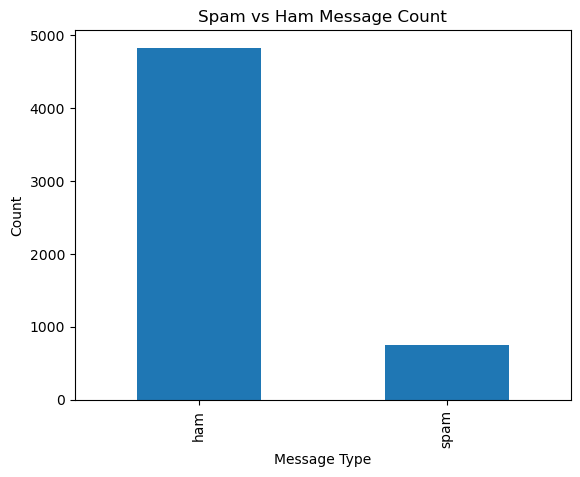

In [10]:
df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Message Count")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

## Convert Labels into Numbers

In [11]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Select Input and Output

In [12]:
X = df["message"]
y = df["label_num"]

## Split the Dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Convert Text into Numbers Using TF-IDF

In [14]:
tfidf = TfidfVectorizer(stop_words="english", lowercase=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Train the Model

In [15]:
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Make Predictions

In [17]:
y_pred = model.predict(X_test_tfidf)

print(y_pred)

[0 0 0 ... 0 0 0]


## Model Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9524663677130045


## Classification Report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.67      0.79       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



## Confusion Matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[962   3]
 [ 50 100]]


## Visualize confusion matrix

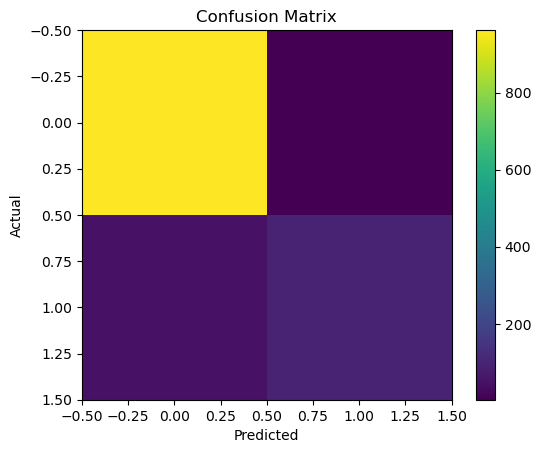

In [21]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

## Test With our Own Message

In [23]:
# example:1

new_message = ["Congratulations! You have won a free iPhone. Click here to claim now."]

new_message_tfidf = tfidf.transform(new_message)

prediction = model.predict(new_message_tfidf)

if prediction[0] == 1:
    print("This message is Spam")
else:
    print("This message is Ham")

This message is Spam


In [25]:
# Example 2

new_message = ["Hey, are we meeting tomorrow for lunch?"]

new_message_tfidf = tfidf.transform(new_message)

prediction = model.predict(new_message_tfidf)

if prediction[0] == 1:
    print("This message is Spam")
else:
    print("This message is Ham")

This message is Ham


## Email Spam Detection Using Machine Learning

In this project, I built a machine learning model to classify messages as spam or ham. Spam messages are unwanted promotional or fraudulent messages, while ham messages are normal messages.

The dataset contains SMS messages and their labels. I cleaned the dataset by selecting only the required columns, converted text labels into numbers, and used TF-IDF Vectorizer to convert message text into numerical values.

After that, I trained a Logistic Regression model and evaluated its performance using accuracy score, classification report, and confusion matrix.